In [2]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

Data Cleaning


In [3]:
df = pd.read_csv('Groceries_dataset.csv')
df_clean = df.copy()

In [3]:
df_clean.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB


In [5]:
df_clean.shape

(38765, 3)

In [5]:
df_clean.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [6]:
df_clean.duplicated().value_counts()

False    38006
True       759
Name: count, dtype: int64

In [7]:
#Menghapus duplikat data
df_clean = df.drop_duplicates()

In [8]:
df_clean.duplicated().value_counts()

False    38006
Name: count, dtype: int64

In [ ]:
def s

In [7]:
df_clean['itemDescription'] = df_clean['itemDescription'].str.strip().str.lower()
df_clean.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [9]:
#mengubah tipe data kolom Date menjadi datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d-%m-%Y')

In [4]:
df_clean.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [10]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 38006 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38006 non-null  int64         
 1   Date             38006 non-null  datetime64[us]
 2   itemDescription  38006 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.2 MB


In [11]:
trx_per_member = df_clean.groupby('Member_number').size()
Q1 = trx_per_member.quantile(0.25)
Q3 = trx_per_member.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
outlier_members = trx_per_member[(trx_per_member < lower_bound) | (trx_per_member > upper_bound)]
print(f"\nBatas IQR jumlah transaksi per member: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Jumlah member outlier (transaksi sangat tinggi/rendah): {len(outlier_members)}")


Batas IQR jumlah transaksi per member: [-4.5, 23.5]
Jumlah member outlier (transaksi sangat tinggi/rendah): 54


In [12]:
df_clean['transaction_id'] = df_clean['Member_number'].astype(str) + '_' + df_clean['Date'].dt.strftime('%Y-%m-%d')
 
df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['month_name'] = df_clean['Date'].dt.month_name()
df_clean['day'] = df_clean['Date'].dt.day
df_clean['day_of_week'] = df_clean['Date'].dt.day_name()
df_clean['weekofyear'] = df_clean['Date'].dt.isocalendar().week
df_clean['is_weekend'] = df_clean['Date'].dt.dayofweek.isin([5, 6])
df_clean['quarter'] = df_clean['Date'].dt.quarter
df_clean.head()

,Member_number,Date,itemDescription,transaction_id,year,month,month_name,day,day_of_week,weekofyear,is_weekend,quarter
0,1808,2015-07-21,tropical fruit,1808_2015-07-21,2015,7,July,21,Tuesday,30,False,3
1,2552,2015-01-05,whole milk,2552_2015-01-05,2015,1,January,5,Monday,2,False,1
2,2300,2015-09-19,pip fruit,2300_2015-09-19,2015,9,September,19,Saturday,38,True,3
3,1187,2015-12-12,other vegetables,1187_2015-12-12,2015,12,December,12,Saturday,50,True,4
4,3037,2015-02-01,whole milk,3037_2015-02-01,2015,2,February,1,Sunday,5,True,1


In [29]:
basket_size = df_clean.groupby('transaction_id')['itemDescription'].transform('count')
df_clean['basket_size'] = basket_size
 
# Jumlah transaksi & total item per member (untuk RFM-style / customer behaviour)
member_stats = df_clean.groupby('Member_number').agg(
    total_transactions=('transaction_id', 'nunique'),
    total_items=('itemDescription', 'count'),
    first_purchase=('Date', 'min'),
    last_purchase=('Date', 'max')
).reset_index()
member_stats['customer_lifetime_days'] = (
    member_stats['last_purchase'] - member_stats['first_purchase']
).dt.days
member_stats['avg_items_per_transaction'] = (
    member_stats['total_items'] / member_stats['total_transactions']
).round(2)
 
df_clean = df_clean.merge(member_stats[['Member_number', 'total_transactions', 'total_items',
                             'customer_lifetime_days', 'avg_items_per_transaction']],
              on='Member_number', how='left')
df_clean.head()

,Member_number,Date,itemDescription,transaction_id,year,month,month_name,day,day_of_week,weekofyear,...,avg_items_per_transaction_x,customer_segment,total_transactions_y,total_items_y,customer_lifetime_days_y,avg_items_per_transaction_y,total_transactions,total_items,customer_lifetime_days,avg_items_per_transaction
0,1808,2015-07-21,tropical fruit,1808_2015-07-21,2015,7,July,21,Tuesday,30,...,2.5,Occasional Buyer,4,10,234,2.5,4,10,234,2.5
1,2552,2015-01-05,whole milk,2552_2015-01-05,2015,1,January,5,Monday,2,...,2.6,Occasional Buyer,5,13,320,2.6,5,13,320,2.6
2,2300,2015-09-19,pip fruit,2300_2015-09-19,2015,9,September,19,Saturday,38,...,2.5,Occasional Buyer,4,10,552,2.5,4,10,552,2.5
3,1187,2015-12-12,other vegetables,1187_2015-12-12,2015,12,December,12,Saturday,50,...,2.0,Occasional Buyer,3,6,552,2.0,3,6,552,2.0
4,3037,2015-02-01,whole milk,3037_2015-02-01,2015,2,February,1,Sunday,5,...,2.5,Occasional Buyer,2,5,22,2.5,2,5,22,2.5


In [14]:
def segment_customer(n):
    if n == 1:
        return 'One-time Buyer'
    elif n <= 5:
        return 'Occasional Buyer'
    elif n <= 15:
        return 'Regular Buyer'
    else:
        return 'Loyal Buyer'
 
df_clean['customer_segment'] = df_clean['total_transactions'].apply(segment_customer)

In [15]:
print("\n" + "="*60)
print("Jumlah baris akhir:", len(df_clean))
print("Jumlah transaksi unik:", df_clean['transaction_id'].nunique())
print("Jumlah member unik:", df_clean['Member_number'].nunique())
print("Jumlah produk unik:", df_clean['itemDescription'].nunique())
print("="*60)


Jumlah baris akhir: 38006
Jumlah transaksi unik: 14963
Jumlah member unik: 3898
Jumlah produk unik: 167


In [16]:
transactions = (
    df_clean.groupby('transaction_id')['itemDescription']
      .apply(list)
      .tolist()
)
print(f'Total Transaksi (basket): {len(transactions)}')
print('Contoh transaksi pertama :', transactions[0])

Total Transaksi (basket): 14963
Contoh transaksi pertama : ['whole milk', 'pastry', 'salty snack']


One HOT Encode

In [17]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
print("\nShape hasil one-hot encoding:", basket_df.shape)


Shape hasil one-hot encoding: (14963, 167)


In [18]:
MIN_SUPPORT = 0.001
frequent_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
print(f"\nJumlah frequent itemsets ditemukan: {len(frequent_itemsets)}")
print(frequent_itemsets.head(10))


Jumlah frequent itemsets ditemukan: 750
      support                       itemsets  length
146  0.157923        frozenset({whole milk})       1
90   0.122101  frozenset({other vegetables})       1
109  0.110005        frozenset({rolls/buns})       1
123  0.097106              frozenset({soda})       1
147  0.085879            frozenset({yogurt})       1
110  0.069572   frozenset({root vegetables})       1
139  0.067767    frozenset({tropical fruit})       1
10   0.060683     frozenset({bottled water})       1
115  0.060349           frozenset({sausage})       1
28   0.053131      frozenset({citrus fruit})       1


In [19]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)
 
# Ubah frozenset jadi string supaya mudah dibaca & diimpor ke Power BI
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
 
cols_to_keep = ['antecedents', 'consequents', 'antecedent support',
                 'consequent support', 'support', 'confidence', 'lift',
                 'leverage', 'conviction']
rules = rules[cols_to_keep]
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
83,sausage,"whole milk, yogurt",0.060349,0.011161,0.001470,0.024363,2.182917,0.000797,1.013532
82,"whole milk, yogurt",sausage,0.011161,0.060349,0.001470,0.131737,2.182917,0.000797,1.082219
80,"sausage, whole milk",yogurt,0.008955,0.085879,0.001470,0.164179,1.911760,0.000701,1.093681
85,yogurt,"sausage, whole milk",0.085879,0.008955,0.001470,0.017121,1.911760,0.000701,1.008307
114,specialty chocolate,citrus fruit,0.015973,0.053131,0.001403,0.087866,1.653762,0.000555,1.038081


In [20]:
print(f"\nJumlah association rules ditemukan: {len(rules)}")
print("\nTop 10 rules berdasarkan lift:")
print(rules.head(10).to_string(index=False))


Jumlah association rules ditemukan: 240

Top 10 rules berdasarkan lift:
        antecedents         consequents  antecedent support  consequent support  support  confidence     lift  leverage  conviction
            sausage  whole milk, yogurt            0.060349            0.011161 0.001470    0.024363 2.182917  0.000797    1.013532
 whole milk, yogurt             sausage            0.011161            0.060349 0.001470    0.131737 2.182917  0.000797    1.082219
sausage, whole milk              yogurt            0.008955            0.085879 0.001470    0.164179 1.911760  0.000701    1.093681
             yogurt sausage, whole milk            0.085879            0.008955 0.001470    0.017121 1.911760  0.000701    1.008307
specialty chocolate        citrus fruit            0.015973            0.053131 0.001403    0.087866 1.653762  0.000555    1.038081
       citrus fruit specialty chocolate            0.053131            0.015973 0.001403    0.026415 1.653762  0.000555    1.010726
   

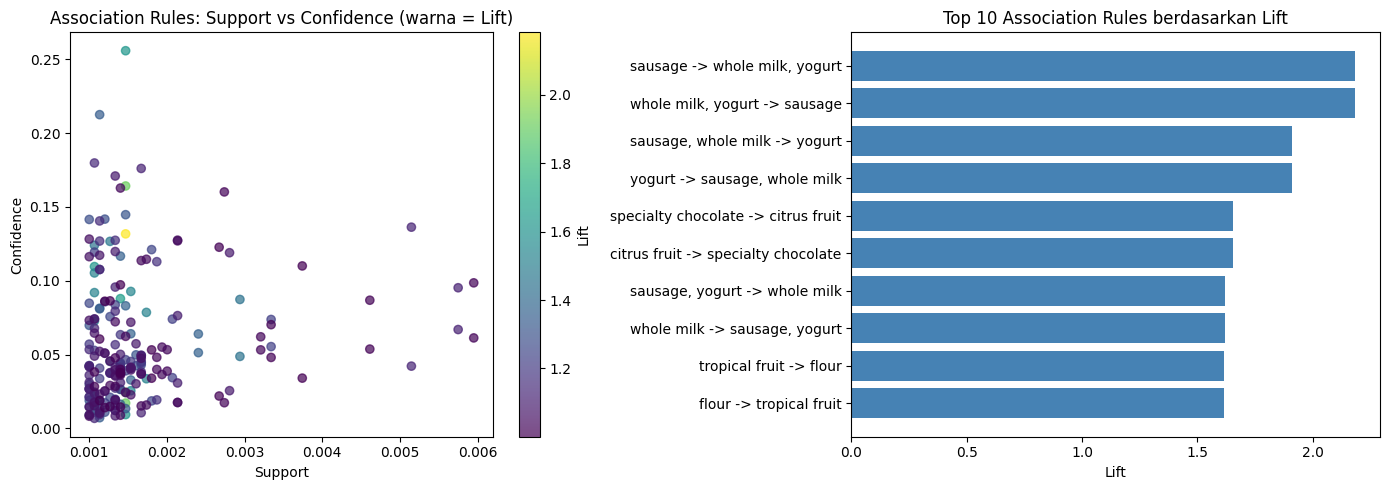


Visualisasi pengecekan disimpan: association_rules_check.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Scatter: support vs confidence, ukuran/warna = lift
sc = axes[0].scatter(rules['support'], rules['confidence'],
                       c=rules['lift'], cmap='viridis', alpha=0.7)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence (warna = Lift)')
plt.colorbar(sc, ax=axes[0], label='Lift')
top10 = rules.head(10).copy()
top10['rule_label'] = top10['antecedents'] + ' -> ' + top10['consequents']
axes[1].barh(top10['rule_label'][::-1], top10['lift'][::-1], color='steelblue')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Association Rules berdasarkan Lift')
 
plt.tight_layout()
plt.show()
print("\nVisualisasi pengecekan disimpan: association_rules_check.png")

<Axes: >

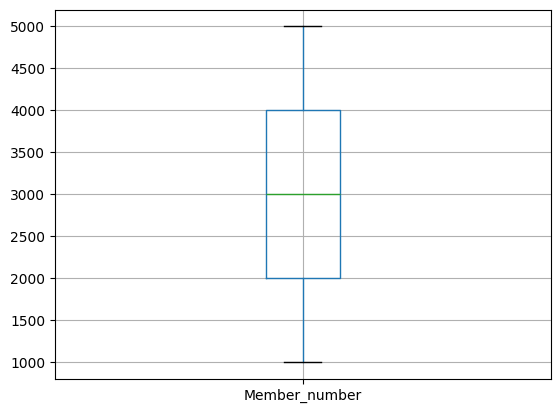

In [22]:
df_clean.boxplot(column= 'Member_number')

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/mba/eda_distribution_numeric.png'

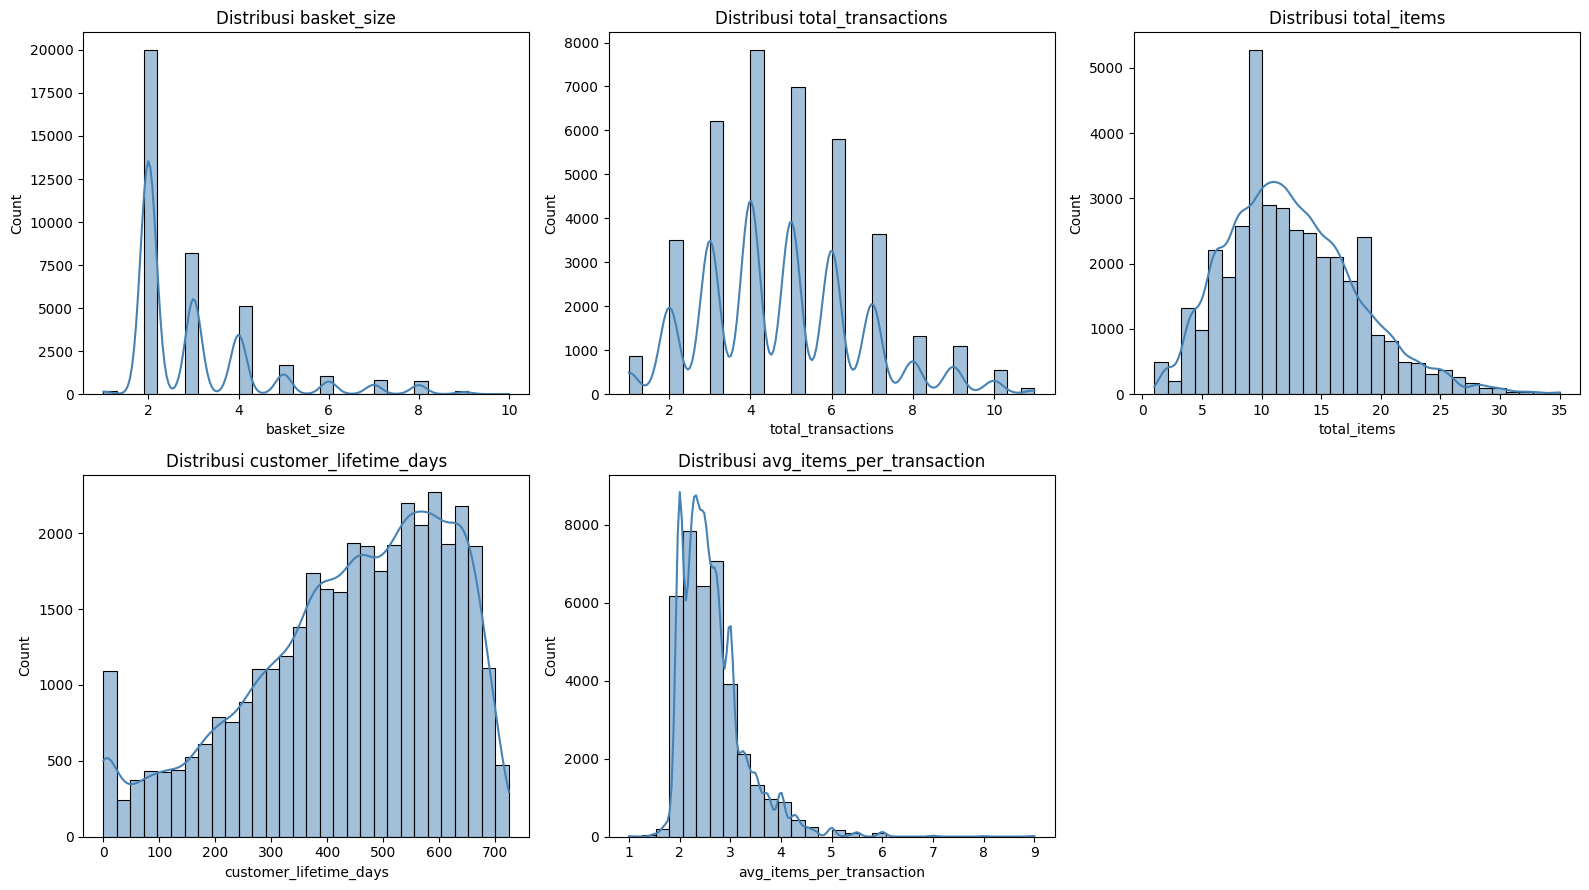

In [27]:
numeric_cols = ['basket_size', 'total_transactions', 'total_items',
                 'customer_lifetime_days', 'avg_items_per_transaction']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
axes[-1].axis('off')  # sisa subplot kosong
plt.tight_layout()
plt.savefig('/home/claude/mba/eda_distribution_numeric.png', dpi=150)
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/mba/eda_distribution_categorical.png'

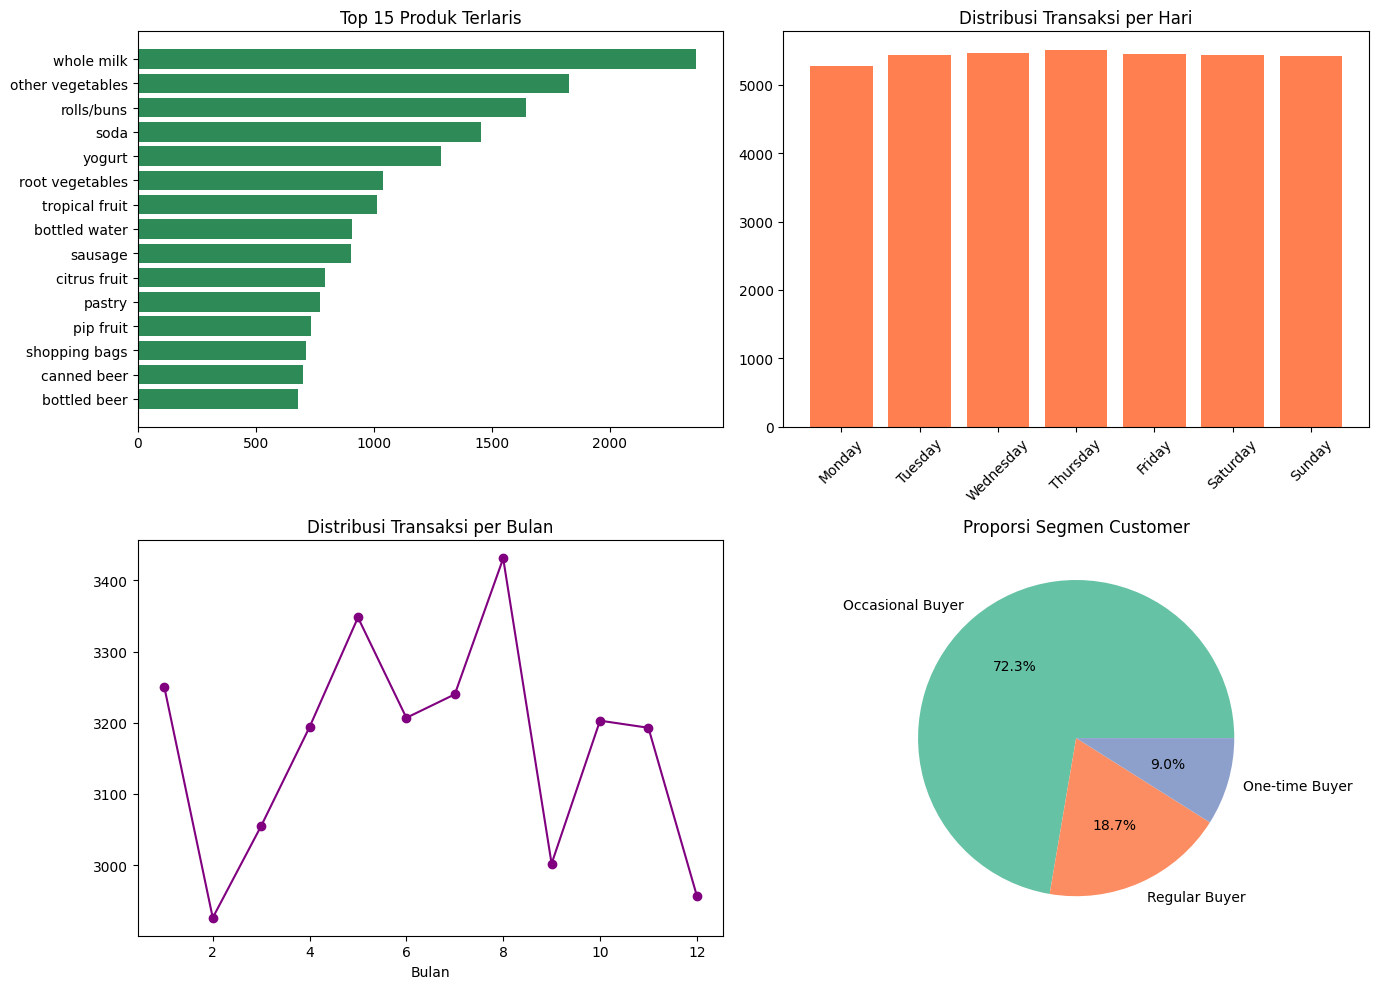

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
top_items = df_clean['itemDescription'].value_counts().head(15)
axes[0, 0].barh(top_items.index[::-1], top_items.values[::-1], color='seagreen')
axes[0, 0].set_title('Top 15 Produk Terlaris')
 
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_count = df_clean['day_of_week'].value_counts().reindex(dow_order)
axes[0, 1].bar(dow_count.index, dow_count.values, color='coral')
axes[0, 1].set_title('Distribusi Transaksi per Hari')
axes[0, 1].tick_params(axis='x', rotation=45)
 
month_count = df_clean.groupby('month')['itemDescription'].count()
axes[1, 0].plot(month_count.index, month_count.values, marker='o', color='purple')
axes[1, 0].set_title('Distribusi Transaksi per Bulan')
axes[1, 0].set_xlabel('Bulan')
 
seg_count = df_clean.drop_duplicates('Member_number')['customer_segment'].value_counts()
axes[1, 1].pie(seg_count.values, labels=seg_count.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2'))
axes[1, 1].set_title('Proporsi Segmen Customer')
 
plt.tight_layout()
plt.savefig('/home/claude/mba/eda_distribution_categorical.png', dpi=150)
plt.close()

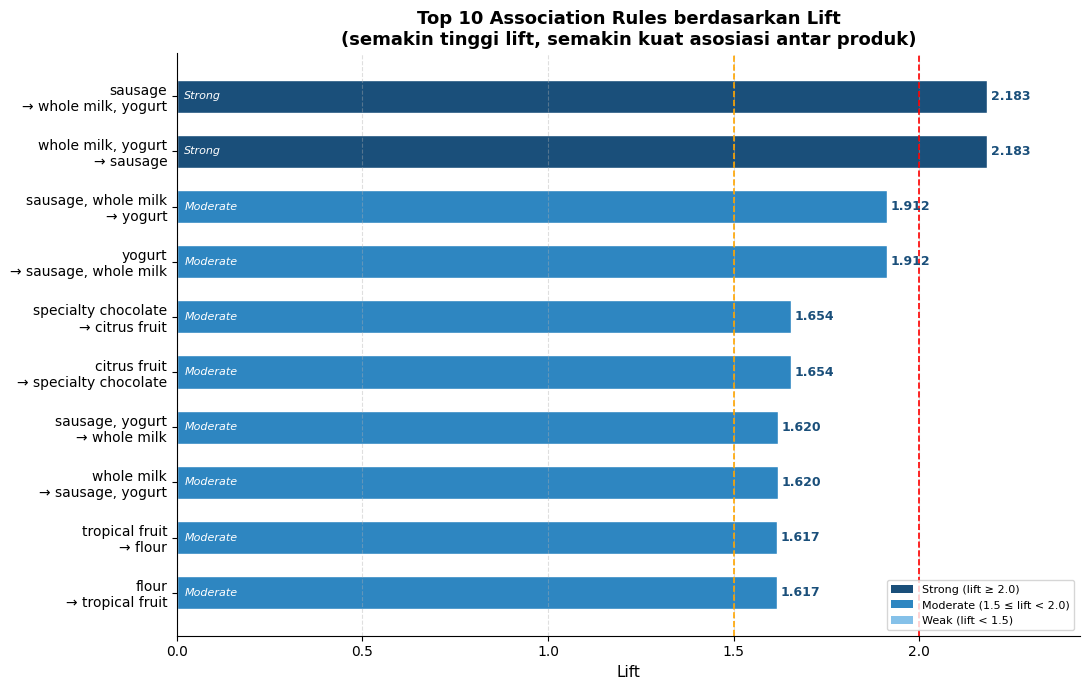

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top10 = rules.nlargest(10, 'lift').copy()
top10['rule'] = top10['antecedents'] + '\n→ ' + top10['consequents']

# Warna bar berdasarkan kekuatan lift
def get_color(lift):
    if lift >= 2.0:
        return '#1a4f7a'   # biru tua = Strong
    elif lift >= 1.5:
        return '#2e86c1'   # biru sedang = Moderate
    else:
        return '#85c1e9'   # biru muda = Weak

colors = [get_color(l) for l in top10['lift']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top10['rule'][::-1],
    top10['lift'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

# Data labels di ujung kanan bar
for bar, val in zip(bars, top10['lift'][::-1]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left',
        fontsize=9, fontweight='bold', color='#1a4f7a'
    )

# Label kekuatan di dalam bar
for bar, val in zip(bars, top10['lift'][::-1]):
    strength = 'Strong' if val >= 2.0 else ('Moderate' if val >= 1.5 else 'Weak')
    ax.text(
        0.02,
        bar.get_y() + bar.get_height() / 2,
        strength,
        va='center', ha='left',
        fontsize=8, color='white', fontstyle='italic'
    )

# Garis threshold
ax.axvline(x=1.5, color='orange', linestyle='--', linewidth=1.2)
ax.axvline(x=2.0, color='red',    linestyle='--', linewidth=1.2)

# Legenda
legend_elements = [
    mpatches.Patch(facecolor='#1a4f7a', label='Strong (lift ≥ 2.0)'),
    mpatches.Patch(facecolor='#2e86c1', label='Moderate (1.5 ≤ lift < 2.0)'),
    mpatches.Patch(facecolor='#85c1e9', label='Weak (lift < 1.5)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

ax.set_xlabel('Lift', fontsize=11)
ax.set_title('Top 10 Association Rules berdasarkan Lift\n(semakin tinggi lift, semakin kuat asosiasi antar produk)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top10['lift'].max() + 0.25)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv('association_rules.csv', index=False)

In [ ]:
df_clean.to_csv('Groceries_dataset_clean.csv', index=False)

In [ ]:
rules = rules.reset_index(drop=True)
rules['rule_id'] = rules.index + 1
rules.to_csv('association_rules3.csv', index=False)

In [ ]:
rules.to_csv('association_rules2.csv', index=False)